# Event-level flood inequality exploration

Scratch notebook for exploring the sequence of DFO flood events affecting one country. It loads the per-event CSV files under `data/results/social_flood/events/DFO_*`, keeps the folder name as the event ID, and filters the country rows by ISO3 code.

The default is Kenya (`KEN`). Change the two country settings below to reuse the notebook elsewhere.

This notebook provides:

- an input audit and event catalogue;
- descriptive summaries by year and flood type;
- event-level CI plots through time, with marker size based on flood exposure (FE);
- a descriptive all-country coverage table; and
- multi-page supplementary CI/FE plots for all countries.

## 1. Imports and configuration

Change `ISO3` and `COUNTRY_NAME` to explore a different country. All event and all-country outputs are descriptive; the notebook does not fit temporal models.

In [1]:
from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

ISO3 = "KEN"
COUNTRY_NAME = "Kenya"
EVENTS_RELATIVE_PATH = Path("data/results/social_flood/events")

TYPE_COLORS = {
    "rain": "blue",
    "snow": "grey",
    "dam": "red",
    "storm": "yellow"
}

In [2]:
def find_project_root(start: Path) -> Path:
    """Find the repository root from either the root or notebooks directory."""
    for candidate in (start, *start.parents):
        if (candidate / EVENTS_RELATIVE_PATH).is_dir():
            return candidate
    raise FileNotFoundError(
        f"Could not find {EVENTS_RELATIVE_PATH} above {start.resolve()}"
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
EVENTS_DIR = PROJECT_ROOT / EVENTS_RELATIVE_PATH

print(f"Project root: {PROJECT_ROOT}")
print(f"Event results: {EVENTS_DIR}")
print(f"Country: {COUNTRY_NAME} ({ISO3})")


Project root: C:\Users\Mark\Projects\flood-risk-inequality-review
Event results: C:\Users\Mark\Projects\flood-risk-inequality-review\data\results\social_flood\events
Country: Kenya (KEN)


## 2. Load the country rows from all events

A DFO result file may contain several countries. Empty result files and events that do not contain the selected country are recorded in `file_audit` instead of causing the load to fail.

In [3]:
REQUIRED_COLUMNS = {"ISO3", "TYPE", "YEAR", "FE", "CI"}
CORE_NUMERIC_COLUMNS = [
    "YEAR", "FE", "BQFE", "CI", "QR",
    "Q1_exp", "Q2_exp", "Q3_exp", "Q4_exp", "Q5_exp",
]


def event_number(event_id: str):
    """Return the numeric part of an event ID where one is available."""
    match = re.search(r"(\d+)", str(event_id))
    return int(match.group(1)) if match else pd.NA


def load_country_events(events_dir: Path, iso3: str):
    """Load all rows for one ISO3 and return event data plus a file-level audit."""
    iso3 = iso3.upper()
    records = []
    audit_records = []
    paths = sorted(events_dir.glob("DFO_*/*_results.csv"))

    if not paths:
        raise FileNotFoundError(f"No event result CSVs found below {events_dir}")

    for path in paths:
        event_id = path.parent.name
        audit = {
            "event_id": event_id,
            "source_file": str(path.relative_to(PROJECT_ROOT)),
        }
        try:
            frame = pd.read_csv(path)
        except (pd.errors.EmptyDataError, pd.errors.ParserError, UnicodeDecodeError) as exc:
            audit.update(status="unreadable_or_empty", detail=type(exc).__name__, loaded_rows=0)
            audit_records.append(audit)
            continue

        frame = frame.loc[:, ~frame.columns.astype(str).str.startswith("Unnamed:")]
        if frame.empty:
            audit.update(status="empty", detail="No data rows", loaded_rows=0)
            audit_records.append(audit)
            continue

        missing = sorted(REQUIRED_COLUMNS - set(frame.columns))
        if missing:
            audit.update(
                status="missing_required_columns",
                detail=", ".join(missing),
                loaded_rows=0,
            )
            audit_records.append(audit)
            continue

        country_rows = frame.loc[
            frame["ISO3"].astype(str).str.upper().eq(iso3)
        ].copy()
        if country_rows.empty:
            audit.update(status="country_not_present", detail="", loaded_rows=0)
            audit_records.append(audit)
            continue

        country_rows["event_id"] = event_id
        country_rows["event_number"] = event_number(event_id)
        country_rows["source_file"] = str(path.relative_to(PROJECT_ROOT))
        records.extend(country_rows.to_dict("records"))
        audit.update(status="loaded", detail="", loaded_rows=len(country_rows))
        audit_records.append(audit)

    if not records:
        raise ValueError(f"No event rows found for ISO3={iso3}")

    events = pd.DataFrame.from_records(records)
    audit = pd.DataFrame.from_records(audit_records)

    numeric_columns = [
        column for column in events.columns
        if column in CORE_NUMERIC_COLUMNS
        or column.endswith(" CI")
        or column.endswith(" Contribution")
        or column.endswith(" Risk Share")
    ]
    for column in numeric_columns:
        events[column] = pd.to_numeric(events[column], errors="coerce")

    events["YEAR"] = events["YEAR"].astype("Int64")
    events["event_number"] = events["event_number"].astype("Int64")
    events["TYPE"] = events["TYPE"].astype(str).str.lower().str.strip()
    events["has_exposure"] = events["FE"].fillna(0).gt(0)
    events["ci_defined"] = events["CI"].notna()

    quintile_columns = [f"Q{i}_exp" for i in range(1, 6)]
    if set(quintile_columns).issubset(events.columns):
        events["quintile_exposure_sum"] = events[quintile_columns].sum(axis=1, min_count=1)
        events["quintile_FE_gap"] = events["quintile_exposure_sum"] - events["FE"]

    events = events.sort_values(["YEAR", "event_number", "TYPE"], na_position="last").reset_index(drop=True)
    return events, audit


In [4]:
events, file_audit = load_country_events(EVENTS_DIR, ISO3)

print(f"Loaded {len(events):,} country rows from {events['event_id'].nunique():,} DFO events.")
display(
    file_audit.groupby("status", dropna=False)
    .agg(files=("source_file", "size"), loaded_rows=("loaded_rows", "sum"))
    .sort_values("files", ascending=False)
)

display(
    events[["event_id", "YEAR", "TYPE", "FE", "BQFE", "CI", "QR"]]
    .head(10)
)


Loaded 32 country rows from 32 DFO events.


,files,loaded_rows
status,,
country_not_present,641,0
empty,240,0
loaded,32,32


,event_id,YEAR,TYPE,FE,BQFE,CI,QR
0,DFO_1917,2002,rain,"1,484.1503",301.5512,-0.2662,0.7124
1,DFO_2649,2005,rain,0.0000,0.0000,NaN,NaN
2,DFO_2952,2006,rain,"9,606.9730","3,312.9697",-0.3301,0.4446
3,DFO_3078,2007,rain,"3,312.5083","1,903.5530",-0.5160,0.0213
4,DFO_3146,2007,rain,390.3415,29.9794,-0.3855,0.0000
5,DFO_3170,2007,rain,"18,053.3520","5,400.4350",-0.2458,0.4710
6,DFO_3235,2007,rain,"19,582.3440","3,395.3350",0.3396,2.9501
7,DFO_3287,2008,rain,46.0770,10.1304,-0.3866,0.0000
8,DFO_3394,2008,rain,0.1672,0.0277,-0.2724,0.0000
9,DFO_3404,2008,rain,1.5719,1.5719,-0.7351,0.0000


## 3. Coverage and data-quality checks

Zero-exposure events usually have undefined CI and are retained in the event catalogue but excluded from CI models. The checks below also flag CI values outside their theoretical range and discrepancies between FE and the five quintile exposures.

In [5]:
duplicate_key = ["event_id", "ISO3", "TYPE"]
duplicate_rows = events.duplicated(duplicate_key, keep=False)
ci_outside_range = events["CI"].notna() & ~events["CI"].between(-1, 1)
positive_fe_missing_ci = events["has_exposure"] & ~events["ci_defined"]

quality_records = [
    ("Event rows", len(events)),
    ("Unique DFO events", events["event_id"].nunique()),
    ("Year range", f"{events['YEAR'].min()}–{events['YEAR'].max()}"),
    ("Flood types", ", ".join(sorted(events["TYPE"].dropna().unique()))),
    ("Zero/non-positive FE rows", int((~events["has_exposure"]).sum())),
    ("Positive-FE rows missing CI", int(positive_fe_missing_ci.sum())),
    ("CI outside [-1, 1]", int(ci_outside_range.sum())),
    ("Duplicate event-country-type rows", int(duplicate_rows.sum())),
]

if "quintile_FE_gap" in events:
    quality_records.append(
        ("Maximum absolute quintile/FE gap", events["quintile_FE_gap"].abs().max())
    )

quality_summary = pd.DataFrame(quality_records, columns=["check", "value"])
display(quality_summary)

if positive_fe_missing_ci.any():
    warnings.warn("Some positive-exposure events have undefined CI; inspect them below.")
    display(events.loc[positive_fe_missing_ci, ["event_id", "YEAR", "TYPE", "FE", "CI"]])

if duplicate_rows.any():
    display(events.loc[duplicate_rows].sort_values(duplicate_key))


,check,value
0,Event rows,32
1,Unique DFO events,32
2,Year range,2002–2018
3,Flood types,rain
4,Zero/non-positive FE rows,3
5,Positive-FE rows missing CI,0
6,"CI outside [-1, 1]",0
7,Duplicate event-country-type rows,0
8,Maximum absolute quintile/FE gap,0.0013


## 4. Descriptive event summaries

`FE-weighted mean CI` is the exposure-weighted average of event-level CIs. It is useful descriptively, but it is **not** the CI of a pooled annual flood footprint; that quantity must be recalculated upstream from the underlying population, wealth, and exposure distribution.

In [6]:
def weighted_mean(values, weights):
    valid = values.notna() & weights.notna() & weights.gt(0)
    if not valid.any():
        return np.nan
    return np.average(values.loc[valid], weights=weights.loc[valid])


summary_by_type = (
    events.groupby("TYPE", observed=True)
    .agg(
        events=("event_id", "nunique"),
        first_year=("YEAR", "min"),
        last_year=("YEAR", "max"),
        positive_exposure_events=("has_exposure", "sum"),
        total_FE=("FE", "sum"),
        median_FE=("FE", "median"),
        maximum_FE=("FE", "max"),
        mean_CI=("CI", "mean"),
        median_CI=("CI", "median"),
        mean_QR=("QR", "mean"),
    )
)
summary_by_type["FE_weighted_mean_CI"] = [
    weighted_mean(group["CI"], group["FE"])
    for _, group in events.groupby("TYPE", observed=True)
]
summary_by_type["share_of_defined_CI_below_zero"] = (
    events.loc[events["CI"].notna()]
    .groupby("TYPE", observed=True)["CI"]
    .apply(lambda values: values.lt(0).mean())
)
display(summary_by_type)

annual_summary = (
    events.groupby(["YEAR", "TYPE"], observed=True)
    .agg(
        event_count=("event_id", "nunique"),
        positive_exposure_events=("has_exposure", "sum"),
        total_FE=("FE", "sum"),
        median_FE=("FE", "median"),
        mean_event_CI=("CI", "mean"),
        median_event_CI=("CI", "median"),
    )
    .reset_index()
)

valid_ci = events.loc[events["CI"].notna() & events["FE"].gt(0)].copy()
valid_ci["FE_x_CI"] = valid_ci["FE"] * valid_ci["CI"]
annual_weighted = (
    valid_ci.groupby(["YEAR", "TYPE"], observed=True)
    .agg(FE_x_CI=("FE_x_CI", "sum"), CI_weight=("FE", "sum"))
    .reset_index()
)
annual_weighted["FE_weighted_mean_CI"] = annual_weighted["FE_x_CI"] / annual_weighted["CI_weight"]
annual_summary = annual_summary.merge(
    annual_weighted[["YEAR", "TYPE", "FE_weighted_mean_CI"]],
    on=["YEAR", "TYPE"],
    how="left",
)

display(annual_summary.head(12))


,events,first_year,last_year,positive_exposure_events,total_FE,median_FE,maximum_FE,mean_CI,median_CI,mean_QR,FE_weighted_mean_CI,share_of_defined_CI_below_zero
TYPE,,,,,,,,,,,,
rain,32,2002,2018,29,"165,108.5847","2,682.6728","19,582.3440",-0.1736,-0.2323,1.3733,-0.1078,0.7586


,YEAR,TYPE,event_count,positive_exposure_events,total_FE,median_FE,mean_event_CI,median_event_CI,FE_weighted_mean_CI
0,2002,rain,1,1,"1,484.1503","1,484.1503",-0.2662,-0.2662,-0.2662
1,2005,rain,1,0,0.0000,0.0000,NaN,NaN,NaN
2,2006,rain,1,1,"9,606.9730","9,606.9730",-0.3301,-0.3301,-0.3301
3,2007,rain,4,4,"41,338.5458","10,682.9302",-0.2019,-0.3157,0.0085
4,2008,rain,3,3,47.8160,1.5719,-0.4647,-0.3866,-0.3976
5,2011,rain,5,4,"24,114.4424","2,690.6830",-0.1760,-0.2090,-0.2441
6,2012,rain,4,4,"43,192.0030","10,497.5675",-0.2338,-0.2236,-0.2304
7,2013,rain,3,3,"14,505.2238","7,133.6360",-0.4365,-0.2651,-0.2413
8,2014,rain,4,3,"2,923.5086",713.2189,0.3166,0.3042,0.3776
9,2015,rain,1,1,"11,455.6857","11,455.6857",0.4573,0.4573,0.4573


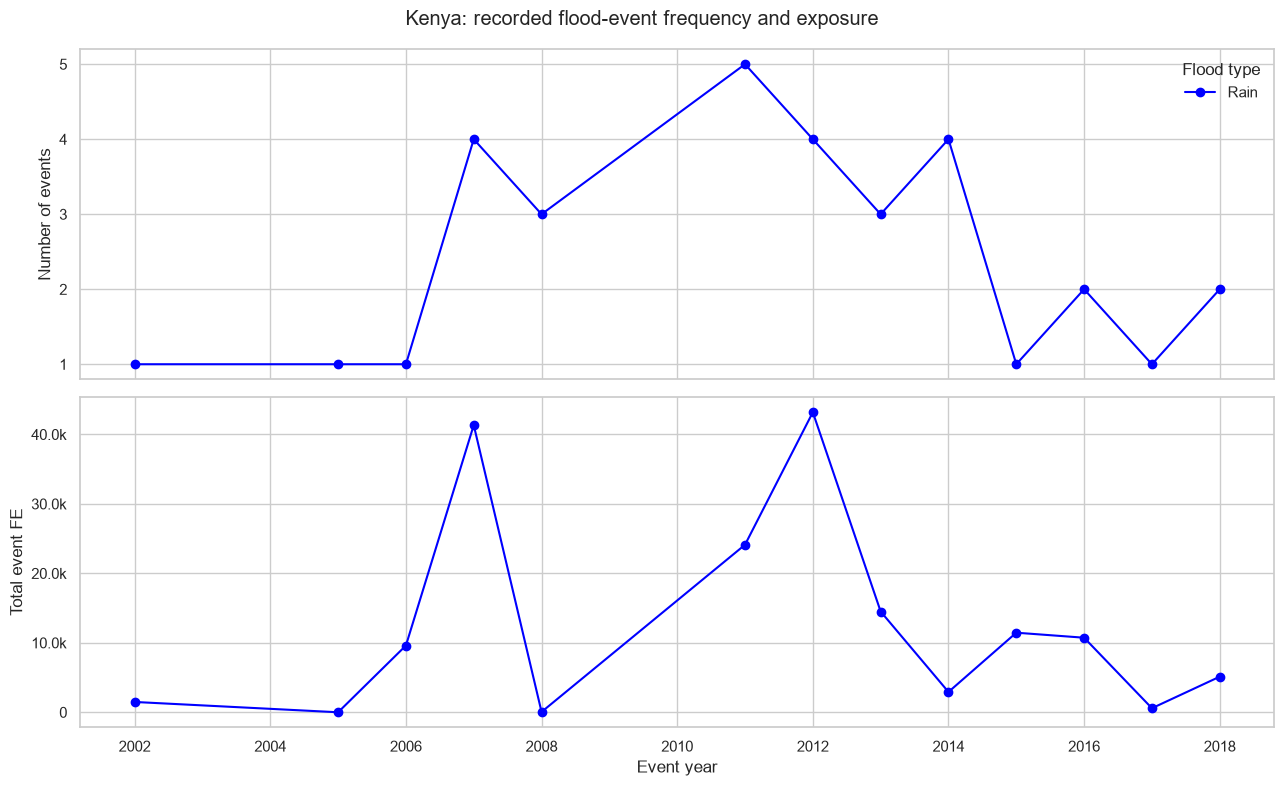

,event_id,YEAR,TYPE,FE,BQFE,CI,QR
0,DFO_3235,2007,rain,"19,582.3440","3,395.3350",0.3396,2.9501
1,DFO_3170,2007,rain,"18,053.3520","5,400.4350",-0.2458,0.4710
2,DFO_3917,2012,rain,"13,234.5770","4,229.7440",-0.2149,0.5499
3,DFO_3875,2011,rain,"12,592.9450","3,305.5320",-0.2070,0.7089
4,DFO_3981,2012,rain,"11,808.8060","3,489.0908",-0.2106,0.7271
5,DFO_4317,2015,rain,"11,455.6857","1,058.8276",0.4573,6.4376
6,DFO_2952,2006,rain,"9,606.9730","3,312.9697",-0.3301,0.4446
7,DFO_3980,2012,rain,"9,186.3290","3,031.1492",-0.2323,0.6691
8,DFO_3991,2012,rain,"8,962.2910","2,716.9410",-0.2773,0.4883
9,DFO_3863,2011,rain,"8,765.9130","2,478.3064",-0.2110,0.8005


In [7]:
def compact_number(value, position=None):
    for scale, suffix in [(1e9, "B"), (1e6, "M"), (1e3, "k")]:
        if abs(value) >= scale:
            return f"{value / scale:,.1f}{suffix}"
    return f"{value:,.0f}"


fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
types = sorted(annual_summary["TYPE"].unique())

for flood_type in types:
    subset = annual_summary.loc[annual_summary["TYPE"].eq(flood_type)]
    color = TYPE_COLORS.get(flood_type)
    axes[0].plot(
        subset["YEAR"], subset["event_count"], marker="o",
        label=flood_type.title(), color=color,
    )
    axes[1].plot(
        subset["YEAR"], subset["total_FE"], marker="o",
        label=flood_type.title(), color=color,
    )

axes[0].set_ylabel("Number of events")
axes[0].yaxis.set_major_locator(MaxNLocator(integer=True))
axes[1].set_ylabel("Total event FE")
axes[1].set_xlabel("Event year")
axes[1].yaxis.set_major_formatter(FuncFormatter(compact_number))
axes[0].legend(title="Flood type", frameon=False, ncol=max(1, len(types)))
fig.suptitle(f"{COUNTRY_NAME}: recorded flood-event frequency and exposure")
fig.tight_layout()
plt.show()

display(
    events.nlargest(15, "FE")
    [["event_id", "YEAR", "TYPE", "FE", "BQFE", "CI", "QR"]]
    .reset_index(drop=True)
)


## 5. CI through time

Each circle is one event and its area increases with FE. Diamonds show the descriptive FE-weighted mean event CI in years containing at least one positive-FE event with defined CI. Negative CI indicates that event exposure is concentrated toward relatively poorer populations; positive CI indicates concentration toward relatively wealthier populations.

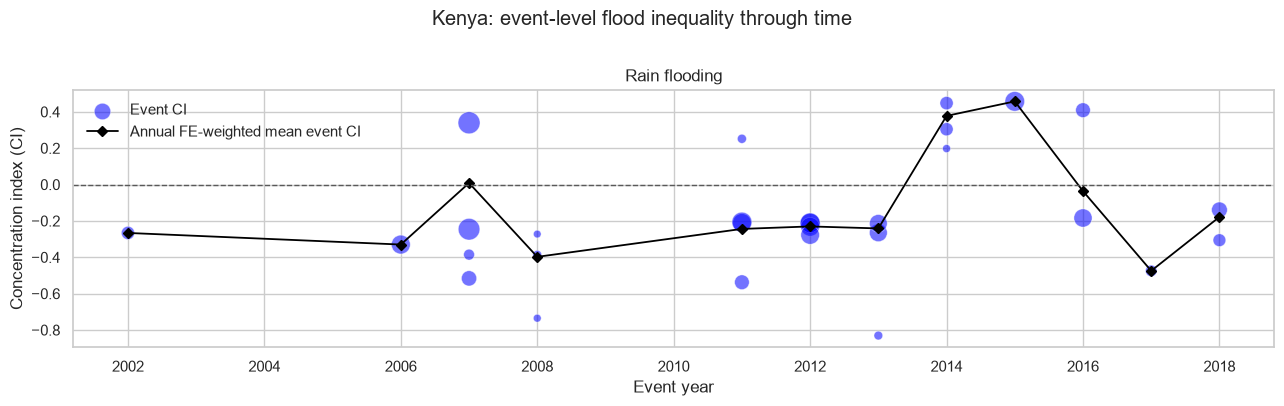

In [8]:
plot_types = sorted(events["TYPE"].dropna().unique())
fig, axes = plt.subplots(
    len(plot_types), 1,
    figsize=(13, max(4, 4 * len(plot_types))),
    sharex=True,
    squeeze=False,
)

for ax, flood_type in zip(axes[:, 0], plot_types):
    subset = events.loc[
        events["TYPE"].eq(flood_type) & events["CI"].notna()
    ].copy()
    positive_fe = subset["FE"].clip(lower=0)
    max_fe = positive_fe.max()
    sizes = 30 + 220 * np.sqrt(positive_fe / max_fe) if max_fe > 0 else 40

    ax.scatter(
        subset["YEAR"], subset["CI"], s=sizes,
        color=TYPE_COLORS.get(flood_type), alpha=0.55,
        edgecolor="white", linewidth=0.5, label="Event CI",
    )

    annual_subset = annual_summary.loc[
        annual_summary["TYPE"].eq(flood_type)
        & annual_summary["FE_weighted_mean_CI"].notna()
    ]
    ax.plot(
        annual_subset["YEAR"], annual_subset["FE_weighted_mean_CI"],
        marker="D", markersize=5, linewidth=1.3,
        color="black", label="Annual FE-weighted mean event CI",
    )
    ax.axhline(0, color="0.35", linewidth=1, linestyle="--")
    ax.set_ylabel("Concentration index (CI)")
    ax.set_title(f"{flood_type.title()} flooding")
    ax.legend(frameon=False, loc="best")

axes[-1, 0].set_xlabel("Event year")
fig.suptitle(f"{COUNTRY_NAME}: event-level flood inequality through time", y=1.01)
fig.tight_layout()
plt.show()


## 6. Event catalogue

The complete country event catalogue is retained for filtering, checking individual events, and linking plotted points back to their DFO identifiers.

In [9]:
event_catalogue_columns = [
    "event_id", "YEAR", "TYPE", "FE", "BQFE", "CI", "QR",
    "Q1_exp", "Q2_exp", "Q3_exp", "Q4_exp", "Q5_exp",
]
event_catalogue = events[
    [column for column in event_catalogue_columns if column in events.columns]
].copy()
display(event_catalogue)

,event_id,YEAR,TYPE,FE,BQFE,CI,QR,Q1_exp,Q2_exp,Q3_exp,Q4_exp,Q5_exp
0,DFO_1917,2002,rain,"1,484.1503",301.5512,-0.2662,0.7124,301.5512,703.7316,97.3124,172.6810,208.8742
1,DFO_2649,2005,rain,0.0000,0.0000,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000
2,DFO_2952,2006,rain,"9,606.9730","3,312.9697",-0.3301,0.4446,"3,312.9695","3,732.8530",767.9717,374.0027,"1,419.1763"
3,DFO_3078,2007,rain,"3,312.5083","1,903.5530",-0.5160,0.0213,"1,903.5530",727.8977,199.6175,442.3651,39.0749
4,DFO_3146,2007,rain,390.3415,29.9794,-0.3855,0.0000,29.9794,355.9960,4.3661,0.0000,0.0000
5,DFO_3170,2007,rain,"18,053.3520","5,400.4350",-0.2458,0.4710,"5,400.4350","5,367.2070","3,279.1910","1,550.9260","2,455.5920"
6,DFO_3235,2007,rain,"19,582.3440","3,395.3350",0.3396,2.9501,"3,395.3352","2,194.7805",412.1890,"3,909.0906","9,670.9500"
7,DFO_3287,2008,rain,46.0770,10.1304,-0.3866,0.0000,10.1304,35.9466,0.0000,0.0000,0.0000
8,DFO_3394,2008,rain,0.1672,0.0277,-0.2724,0.0000,0.0277,0.0000,0.1395,0.0000,0.0000
9,DFO_3404,2008,rain,1.5719,1.5719,-0.7351,0.0000,1.5719,0.0000,0.0000,0.0000,0.0000


## Interpretation checklist

- Inspect event counts and FE before interpreting apparent temporal patterns; later years with more detected events can change the sample composition.
- Treat annual FE-weighted mean CI as a descriptive average of event CIs, not a reconstructed annual CI.
- Give less interpretive weight to extreme CI values arising from very small exposed populations.
- Compare inland and coastal events descriptively only where both types have adequate coverage.
- Remember that event availability may reflect changes in event detection or data coverage as well as flood occurrence.

# Supplementary figure: all-country event trajectories

This section creates publication-oriented small multiples for every country with at least one positive-FE event and a defined CI. Each country panel uses:

- event year on a common x-axis;
- CI on a common −1 to +1 y-axis;
- globally consistent point sizes representing FE categories;
- colour to distinguish flood type; and
- horizontal jitter where multiple events occur in the same year.

Events are deliberately shown as points without connecting lines because they are discrete and irregularly observed. The output is split into several 3-column pages rather than compressed into a single unreadable figure.

In [10]:
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D

try:
    import pycountry
except ImportError:
    pycountry = None

# Publication layout and export settings.
SUPPLEMENT_COLUMNS = 3
SUPPLEMENT_ROWS = 5
SUPPLEMENT_COUNTRIES_PER_PAGE = SUPPLEMENT_COLUMNS * SUPPLEMENT_ROWS
SUPPLEMENT_FIGSIZE = (8.27, 11.69)  # A4 portrait, inches
SUPPLEMENT_DPI = 300
SAVE_SUPPLEMENTARY_OUTPUTS = True
SUPPLEMENT_OUTPUT_DIR = PROJECT_ROOT / "figures" / "supplementary_event_CI_FE"

# Fixed global FE categories: marker sizes never rescale between countries or pages.
FE_BIN_EDGES = [0, 1_000, 10_000, 100_000, 1_000_000, np.inf]
FE_BIN_LABELS = ["<1k", "1k–10k", "10k–100k", "100k–1m", "≥1m"]
FE_MARKER_SIZES = [16, 30, 52, 82, 120]
FE_SIZE_MAP = dict(zip(FE_BIN_LABELS, FE_MARKER_SIZES))

COUNTRY_NAME_OVERRIDES = {
    "BOL": "Bolivia",
    "CIV": "Côte d’Ivoire",
    "COG": "Republic of the Congo",
    "IRN": "Iran",
    "KOR": "South Korea",
    "LAO": "Laos",
    "MDA": "Moldova",
    "MKD": "North Macedonia",
    "SWZ": "Eswatini",
    "TUR": "Türkiye",
    "TZA": "Tanzania",
    "VNM": "Vietnam",
}


def country_name_from_iso3(iso3):
    """Return a concise country name, falling back safely to the ISO3 code."""
    iso3 = str(iso3).upper()
    if iso3 in COUNTRY_NAME_OVERRIDES:
        return COUNTRY_NAME_OVERRIDES[iso3]
    if pycountry is not None:
        country = pycountry.countries.get(alpha_3=iso3)
        if country is not None:
            return country.name
    return iso3


def load_all_event_results(events_dir):
    """Read every event file once and return all valid country rows plus an audit."""
    frames = []
    audit_records = []
    paths = sorted(events_dir.glob("DFO_*/*_results.csv"))

    for path in paths:
        event_id = path.parent.name
        audit = {
            "event_id": event_id,
            "source_file": str(path.relative_to(PROJECT_ROOT)),
        }
        try:
            frame = pd.read_csv(path)
        except (pd.errors.EmptyDataError, pd.errors.ParserError, UnicodeDecodeError) as exc:
            audit.update(status="unreadable_or_empty", rows=0, detail=type(exc).__name__)
            audit_records.append(audit)
            continue

        frame = frame.loc[:, ~frame.columns.astype(str).str.startswith("Unnamed:")]
        if frame.empty:
            audit.update(status="empty", rows=0, detail="No data rows")
            audit_records.append(audit)
            continue

        missing = sorted(REQUIRED_COLUMNS - set(frame.columns))
        if missing:
            audit.update(
                status="missing_required_columns",
                rows=0,
                detail=", ".join(missing),
            )
            audit_records.append(audit)
            continue

        frame["event_id"] = event_id
        frame["event_number"] = event_number(event_id)
        frame["source_file"] = str(path.relative_to(PROJECT_ROOT))
        frames.append(frame)
        audit.update(status="loaded", rows=len(frame), detail="")
        audit_records.append(audit)

    if not frames:
        raise ValueError(f"No usable event result files found below {events_dir}")

    all_events = pd.concat(frames, ignore_index=True, sort=False)
    all_audit = pd.DataFrame.from_records(audit_records)

    numeric_columns = [
        column for column in all_events.columns
        if column in CORE_NUMERIC_COLUMNS
        or column.endswith(" CI")
        or column.endswith(" Contribution")
        or column.endswith(" Risk Share")
    ]
    for column in numeric_columns:
        all_events[column] = pd.to_numeric(all_events[column], errors="coerce")

    all_events["ISO3"] = all_events["ISO3"].astype(str).str.upper().str.strip()
    all_events["TYPE"] = all_events["TYPE"].astype(str).str.lower().str.strip()
    all_events["YEAR"] = all_events["YEAR"].astype("Int64")
    all_events["event_number"] = all_events["event_number"].astype("Int64")
    all_events["has_exposure"] = all_events["FE"].fillna(0).gt(0)
    all_events["ci_defined"] = all_events["CI"].notna()
    all_events["country_name"] = all_events["ISO3"].map(country_name_from_iso3)
    return all_events, all_audit


In [11]:
all_events, all_event_file_audit = load_all_event_results(EVENTS_DIR)
all_valid_events = all_events.loc[
    all_events["YEAR"].notna()
    & all_events["FE"].gt(0)
    & all_events["CI"].notna()
    & all_events["CI"].between(-1, 1)
].copy()

all_valid_events["FE_category"] = pd.cut(
    all_valid_events["FE"],
    bins=FE_BIN_EDGES,
    labels=FE_BIN_LABELS,
    right=False,
    include_lowest=True,
)
all_valid_events["marker_size"] = (
    all_valid_events["FE_category"].map(FE_SIZE_MAP).astype(float)
)

# Deterministic within-year jitter reveals events that would otherwise overlap.
all_valid_events = all_valid_events.sort_values(
    ["country_name", "ISO3", "YEAR", "event_number"]
).reset_index(drop=True)
year_groups = all_valid_events.groupby(["ISO3", "YEAR"], observed=True)
all_valid_events["within_year_index"] = year_groups.cumcount()
all_valid_events["events_in_country_year"] = year_groups["event_id"].transform("size")
jitter_step = np.zeros(len(all_valid_events), dtype=float)
multiple_events = all_valid_events["events_in_country_year"].gt(1)
jitter_step[multiple_events] = (
    0.5
    / (all_valid_events.loc[multiple_events, "events_in_country_year"] - 1)
)
all_valid_events["plot_year"] = (
    all_valid_events["YEAR"].astype(float)
    + (
        all_valid_events["within_year_index"]
        - (all_valid_events["events_in_country_year"] - 1) / 2
    )
    * jitter_step
)

coverage_overview = pd.DataFrame(
    {
        "measure": [
            "Event CSV files scanned",
            "Event CSV files loaded",
            "All country-event rows",
            "Positive-FE rows with defined in-range CI",
            "Countries represented in valid event rows",
            "Event year range",
            "Flood types represented",
        ],
        "value": [
            len(all_event_file_audit),
            int(all_event_file_audit["status"].eq("loaded").sum()),
            len(all_events),
            len(all_valid_events),
            all_valid_events["ISO3"].nunique(),
            f"{all_valid_events['YEAR'].min()}–{all_valid_events['YEAR'].max()}",
            ", ".join(sorted(all_valid_events["TYPE"].unique())),
        ],
    }
)
display(coverage_overview)

print(
    f"The current exports provide plottable CI/FE data for "
    f"{all_valid_events['ISO3'].nunique()} countries. "
    "The page count is calculated from the data rather than hard-coded."
)


,measure,value
0,Event CSV files scanned,913
1,Event CSV files loaded,673
2,All country-event rows,1950
3,Positive-FE rows with defined in-range CI,1778
4,Countries represented in valid event rows,92
5,Event year range,2000–2018
6,Flood types represented,"dam, rain, snow, storm"


The current exports provide plottable CI/FE data for 92 countries. The page count is calculated from the data rather than hard-coded.


## Country coverage and descriptive summary

The summary table supports the figure and provides a reproducible coverage check. It reports event availability, exposure, and the distribution of event-level CI without estimating temporal trends.

In [12]:
country_summary_records = []

for iso3, group in all_valid_events.groupby("ISO3", observed=True):
    country_summary_records.append(
        {
            "ISO3": iso3,
            "country_name": group["country_name"].iloc[0],
            "valid_events": group["event_id"].nunique(),
            "years_with_events": group["YEAR"].nunique(),
            "first_year": int(group["YEAR"].min()),
            "last_year": int(group["YEAR"].max()),
            "flood_types": ", ".join(sorted(group["TYPE"].unique())),
            "inland_events": int(group["TYPE"].eq("inland").sum()),
            "coastal_events": int(group["TYPE"].eq("coastal").sum()),
            "total_event_FE": group["FE"].sum(),
            "median_event_FE": group["FE"].median(),
            "mean_event_CI": group["CI"].mean(),
            "median_event_CI": group["CI"].median(),
            "FE_weighted_mean_event_CI": weighted_mean(group["CI"], group["FE"]),
            "share_event_CI_below_zero": group["CI"].lt(0).mean(),
        }
    )

all_country_summary = (
    pd.DataFrame.from_records(country_summary_records)
    .sort_values(["country_name", "ISO3"])
    .reset_index(drop=True)
)

display(all_country_summary)

if SAVE_SUPPLEMENTARY_OUTPUTS:
    SUPPLEMENT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    summary_path = SUPPLEMENT_OUTPUT_DIR / "event_CI_FE_country_summary.csv"
    all_country_summary.to_csv(summary_path, index=False)
    print(f"Saved descriptive country summary: {summary_path}")

,ISO3,country_name,valid_events,years_with_events,first_year,last_year,flood_types,inland_events,coastal_events,total_event_FE,median_event_FE,mean_event_CI,median_event_CI,FE_weighted_mean_event_CI,share_event_CI_below_zero
0,ALB,Albania,22,11,2002,2018,"dam, rain, snow",0,0,"118,837.5637","3,624.3827",-0.1279,-0.1248,-0.0244,0.7273
1,DZA,Algeria,6,5,2005,2012,rain,0,0,"160,320.6749","14,100.6495",0.1056,0.2501,0.3321,0.3333
2,AGO,Angola,16,10,2003,2018,"dam, rain",0,0,"28,567.0471",459.9654,-0.3482,-0.3661,0.1600,0.7500
3,ARG,Argentina,45,15,2001,2018,"rain, snow, storm",0,0,"281,456.8936","3,355.0889",-0.3665,-0.3479,-0.2437,0.8444
4,ARM,Armenia,3,3,2002,2005,rain,0,0,"2,446.8399",165.1054,-0.5497,-0.3757,-0.3309,1.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,UKR,Ukraine,17,7,2000,2016,"rain, snow",0,0,"1,579,919.6913","7,191.2140",-0.3105,-0.2347,-0.1120,0.8824
88,UZB,Uzbekistan,9,6,2004,2015,"dam, rain, snow",0,0,"30,359.3457",666.7679,-0.2222,-0.1727,-0.0275,0.8889
89,VNM,Vietnam,59,19,2000,2018,"rain, storm",0,0,"40,151,687.2905","275,485.5166",-0.5104,-0.5285,-0.5049,1.0000
90,ZMB,Zambia,17,10,2002,2018,"dam, rain",0,0,"108,923.0457","1,922.3557",-0.4145,-0.4933,-0.3671,0.9412


Saved descriptive country summary: C:\Users\Mark\Projects\flood-risk-inequality-review\figures\supplementary_event_CI_FE\event_CI_FE_country_summary.csv


## Multi-page country panels

Countries are ordered alphabetically for easy lookup. All pages share the same axes and FE-size categories. The combined PDF is the primary supplementary output; page-level PNG files are also written for convenient review.

In [13]:
def supplementary_legend_handles(flood_types):
    """Create one compact, globally consistent legend for each page."""
    type_handles = [
        Line2D(
            [0], [0], marker="o", linestyle="none", markersize=5.5,
            markerfacecolor=TYPE_COLORS.get(flood_type, "#666666"),
            markeredgecolor="white", markeredgewidth=0.4,
            label=flood_type.title(),
        )
        for flood_type in flood_types
    ]
    size_handles = [
        Line2D(
            [0], [0], marker="o", linestyle="none",
            markersize=np.sqrt(size), markerfacecolor="#777777",
            markeredgecolor="white", markeredgewidth=0.4,
            label=f"FE {label}",
        )
        for label, size in FE_SIZE_MAP.items()
    ]
    return type_handles + size_handles


def make_supplementary_country_pages(
    plot_data,
    country_summary,
    save_outputs=True,
    output_dir=SUPPLEMENT_OUTPUT_DIR,
):
    """Display and optionally save multi-page CI/FE small multiples."""
    country_order = country_summary["ISO3"].tolist()
    n_countries = len(country_order)
    n_pages = int(np.ceil(n_countries / SUPPLEMENT_COUNTRIES_PER_PAGE))
    year_min = int(plot_data["YEAR"].min())
    year_max = int(plot_data["YEAR"].max())
    x_ticks = sorted(set([year_min, 2006, 2012, year_max]))
    flood_types = sorted(plot_data["TYPE"].unique())
    legend_handles = supplementary_legend_handles(flood_types)

    pdf_writer = None
    if save_outputs:
        output_dir.mkdir(parents=True, exist_ok=True)
        pdf_path = output_dir / "event_CI_FE_all_countries.pdf"
        pdf_writer = PdfPages(pdf_path)

    try:
        for page_index in range(n_pages):
            page_countries = country_order[
                page_index * SUPPLEMENT_COUNTRIES_PER_PAGE:
                (page_index + 1) * SUPPLEMENT_COUNTRIES_PER_PAGE
            ]
            fig, axes = plt.subplots(
                SUPPLEMENT_ROWS,
                SUPPLEMENT_COLUMNS,
                figsize=SUPPLEMENT_FIGSIZE,
                sharex=True,
                sharey=True,
                squeeze=False,
            )
            flat_axes = axes.ravel()

            for ax, iso3 in zip(flat_axes, page_countries):
                subset = plot_data.loc[plot_data["ISO3"].eq(iso3)]
                country_name = subset["country_name"].iloc[0]

                for flood_type, type_subset in subset.groupby("TYPE", observed=True):
                    ax.scatter(
                        type_subset["plot_year"],
                        type_subset["CI"],
                        s=type_subset["marker_size"],
                        color=TYPE_COLORS.get(flood_type, "#666666"),
                        alpha=0.68,
                        edgecolor="white",
                        linewidth=0.35,
                        rasterized=True,
                    )

                ax.axhline(0, color="0.35", linewidth=0.65, linestyle="--", zorder=0)
                ax.set_xlim(year_min - 0.7, year_max + 0.7)
                ax.set_ylim(-1.04, 1.04)
                ax.set_xticks(x_ticks)
                ax.set_xticklabels([str(year)[-2:] for year in x_ticks])
                ax.set_yticks([-1, 0, 1])
                ax.tick_params(axis="both", labelsize=6, length=2, pad=1)
                ax.tick_params(axis="x", labelbottom=True)
                ax.grid(axis="y", color="0.9", linewidth=0.45)
                ax.grid(axis="x", visible=False)
                ax.set_title(
                    f"{country_name} ({iso3}) · n={len(subset)}",
                    fontsize=7.3,
                    fontweight="semibold",
                    pad=2,
                )

            for ax in flat_axes[len(page_countries):]:
                ax.set_visible(False)

            fig.suptitle(
                "Event-level flood inequality and exposure through time "
                f"({page_index + 1}/{n_pages})",
                fontsize=11,
                fontweight="semibold",
                y=0.992,
            )
            fig.supxlabel("Event year (two-digit labels)", fontsize=8, y=0.055)
            fig.supylabel("Concentration index (CI)", fontsize=8, x=0.015)
            fig.legend(
                handles=legend_handles,
                loc="lower center",
                bbox_to_anchor=(0.5, 0.012),
                ncol=min(6, len(legend_handles)),
                frameon=False,
                fontsize=6.5,
                handletextpad=0.35,
                columnspacing=0.9,
            )
            fig.subplots_adjust(
                left=0.075, right=0.985, top=0.965, bottom=0.09,
                hspace=0.42, wspace=0.14,
            )

            if save_outputs:
                pdf_writer.savefig(fig, bbox_inches="tight")
                png_path = output_dir / f"event_CI_FE_all_countries_page_{page_index + 1:02d}.png"
                fig.savefig(png_path, dpi=SUPPLEMENT_DPI, bbox_inches="tight")

            plt.show()
    finally:
        if pdf_writer is not None:
            pdf_writer.close()

    if save_outputs:
        print(f"Saved {n_pages} figure pages and combined PDF to: {output_dir}")
    return n_pages


findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


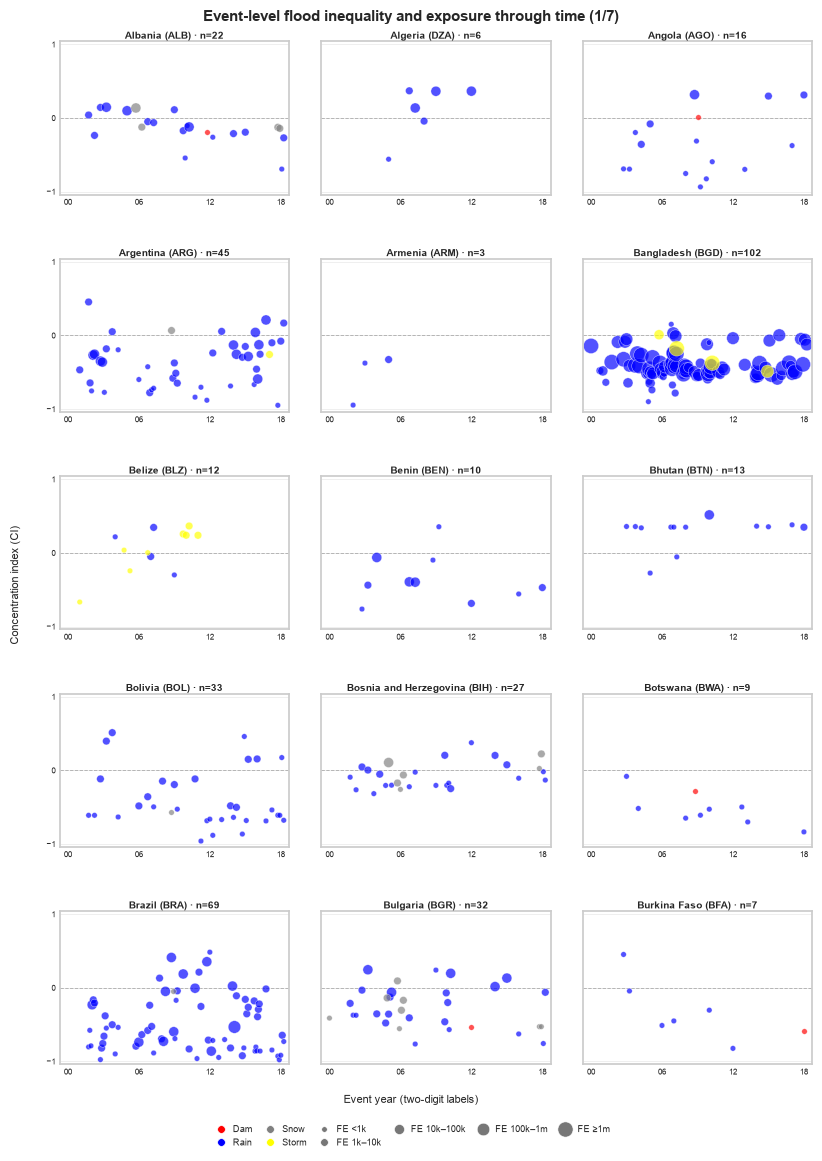

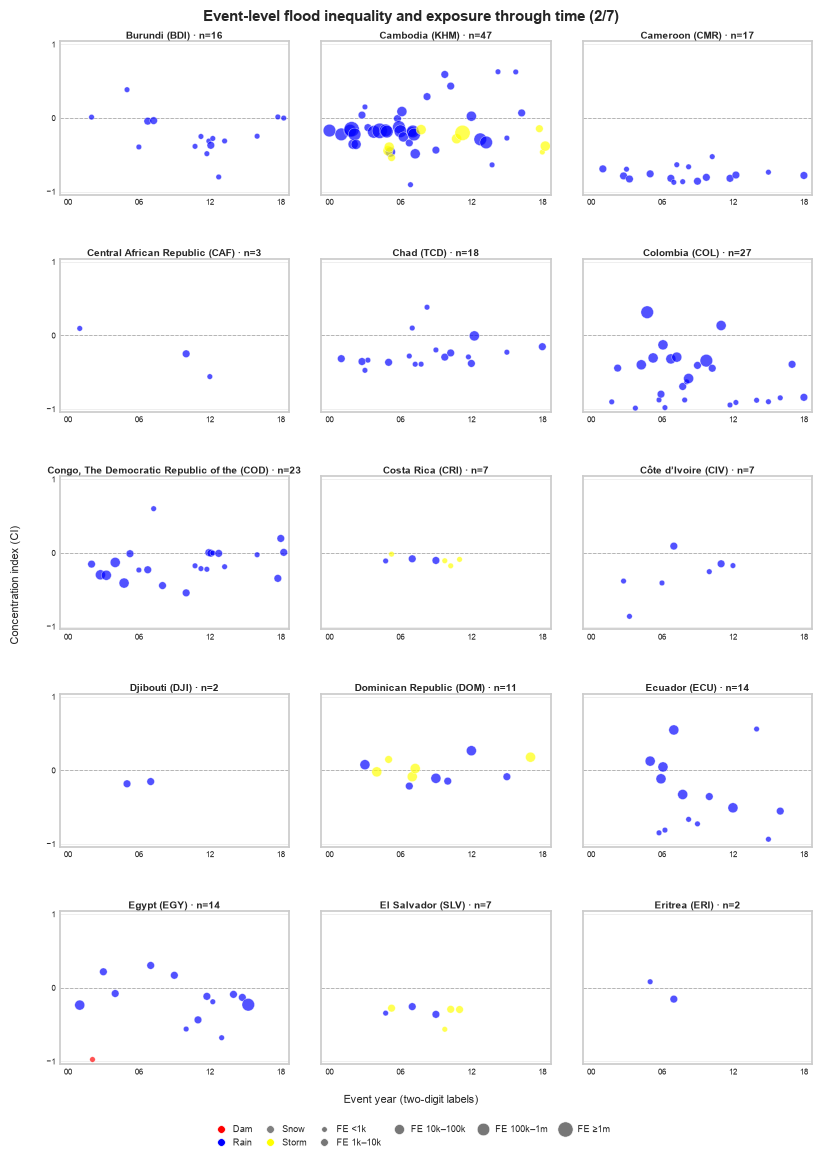

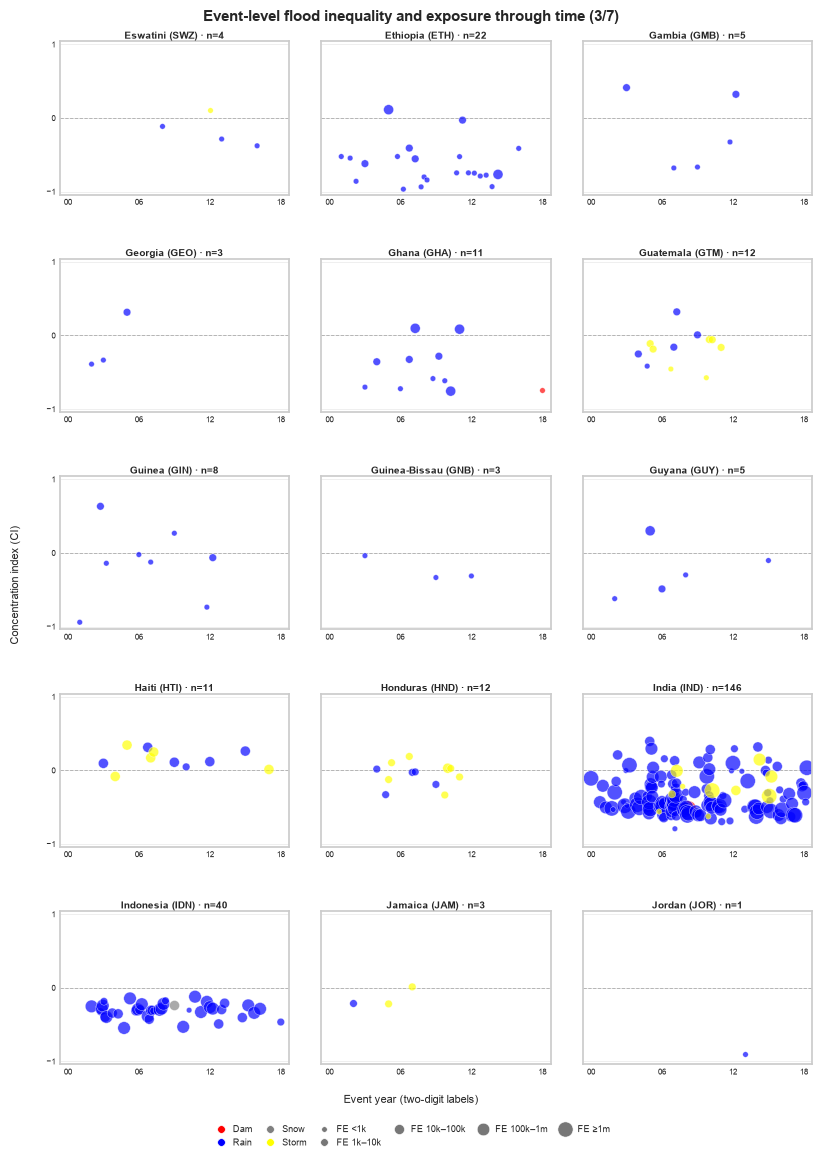

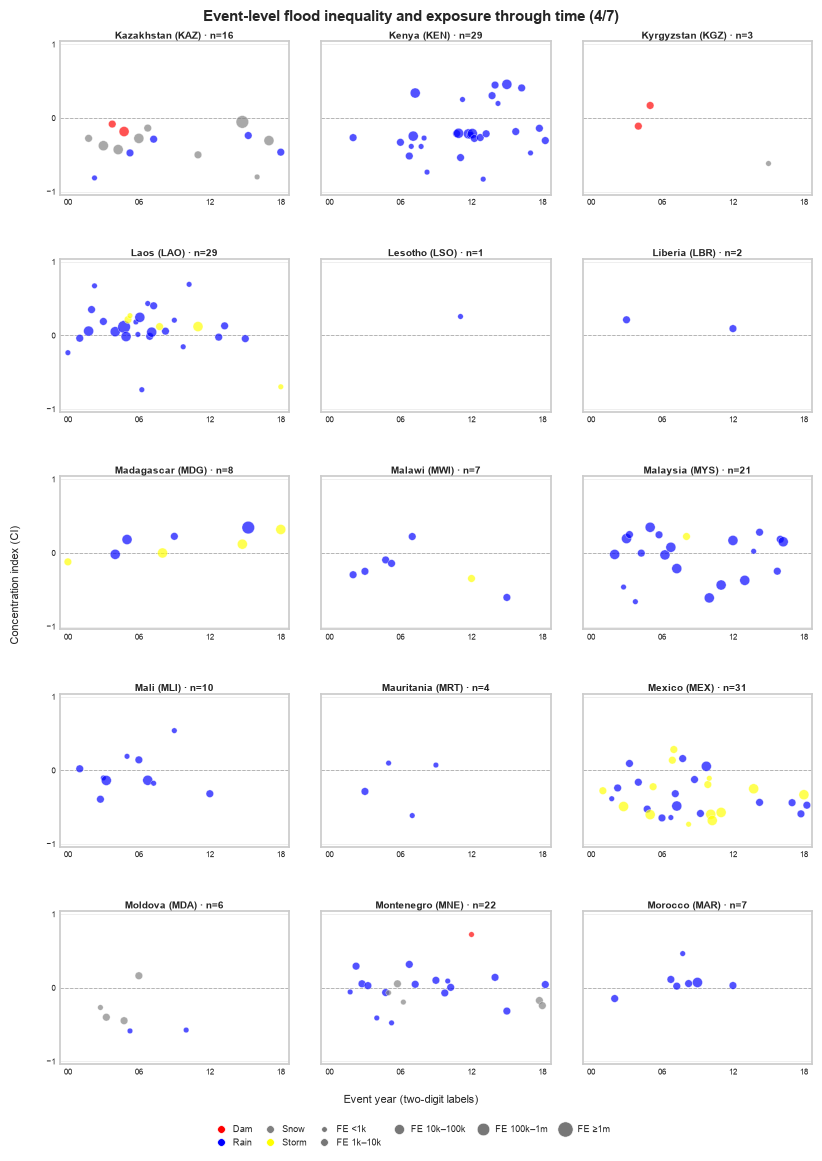

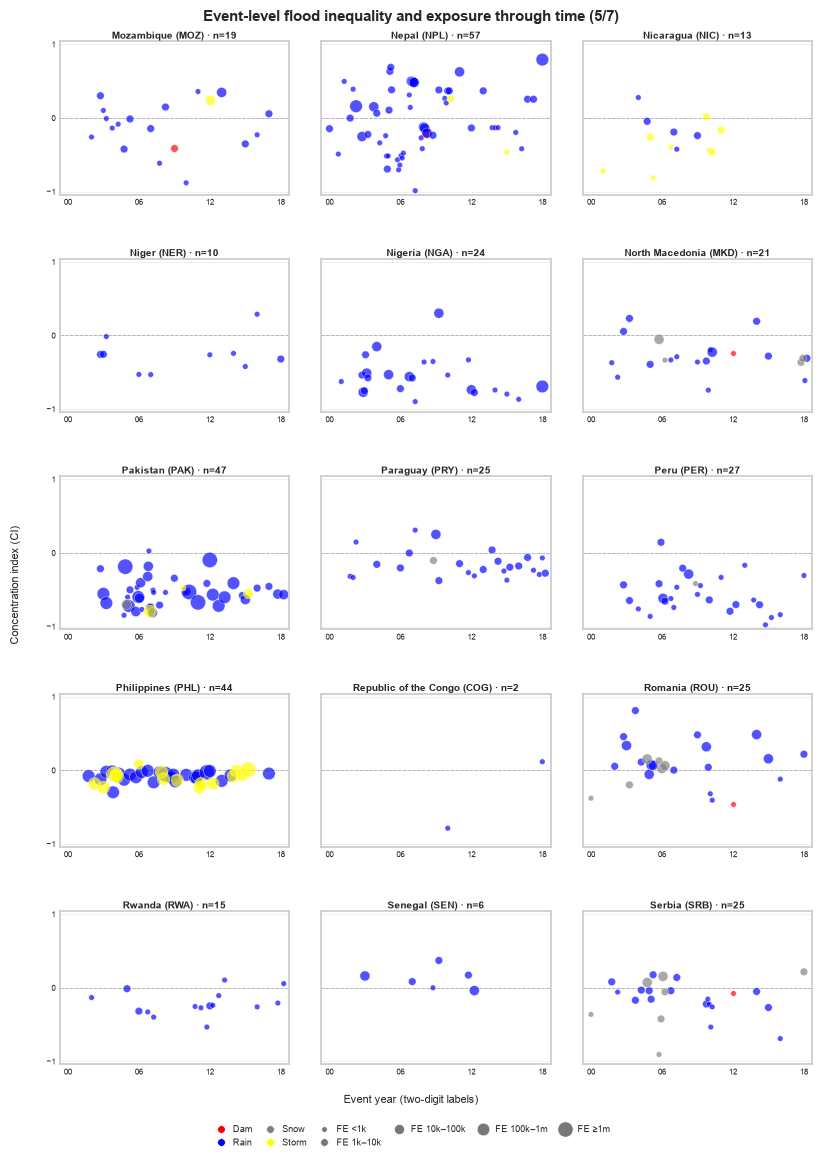

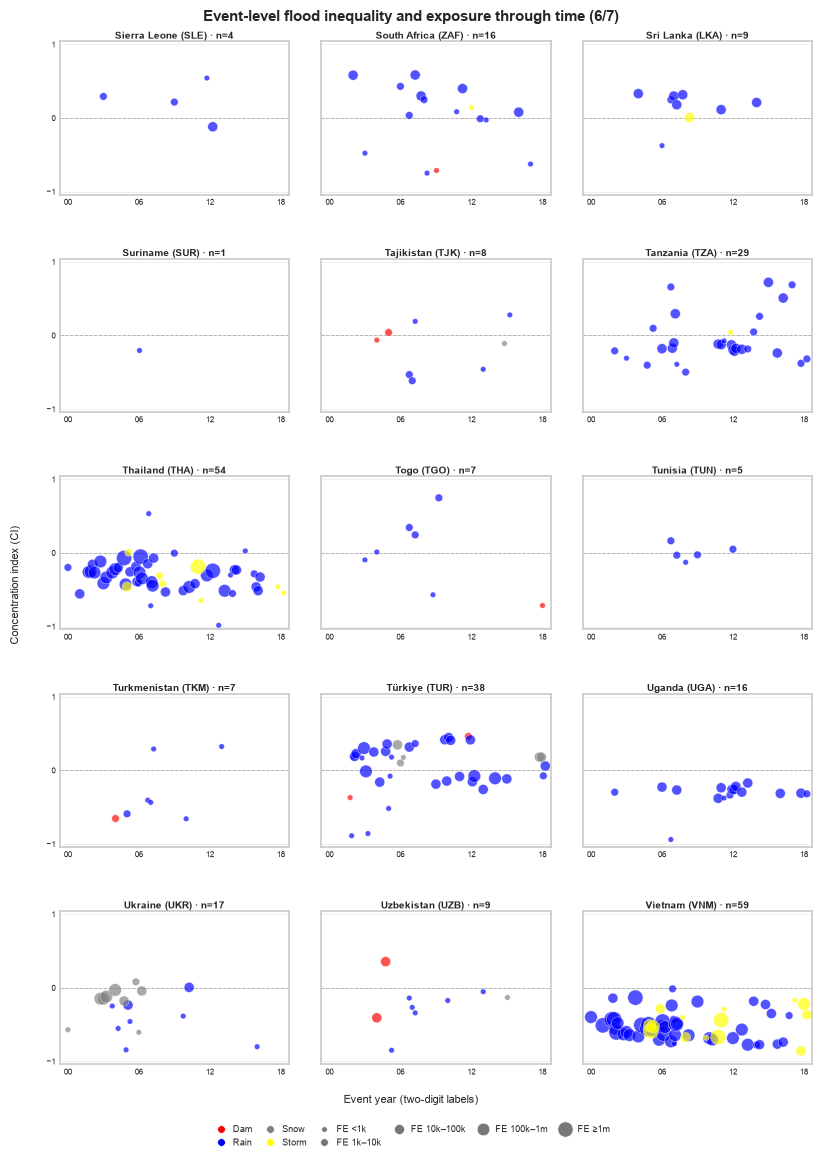

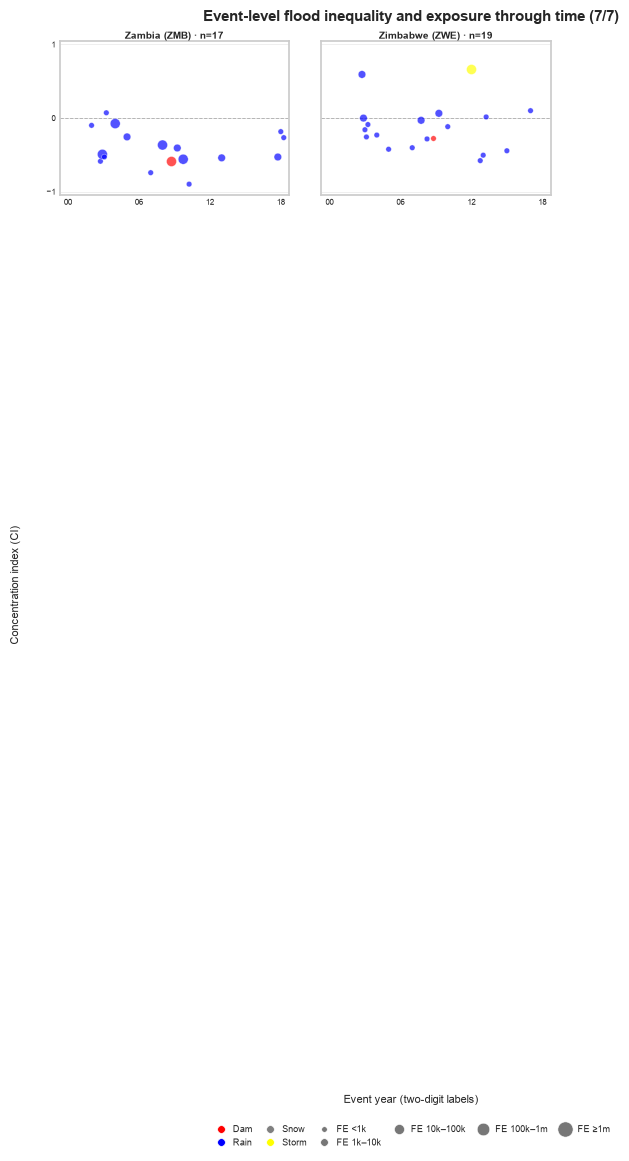

Saved 7 figure pages and combined PDF to: C:\Users\Mark\Projects\flood-risk-inequality-review\figures\supplementary_event_CI_FE


In [14]:
supplement_page_count = make_supplementary_country_pages(
    all_valid_events,
    all_country_summary,
    save_outputs=SAVE_SUPPLEMENTARY_OUTPUTS,
)


## Suggested supplementary caption

**Figure Sx. Event-level flood exposure inequality through time by country.** Each point represents one observed DFO flood event with positive flood exposure (FE) and a defined concentration index (CI). Point size denotes FE using categories shared across every panel, and colour denotes flood type. Negative CI indicates that exposure is disproportionately concentrated among relatively poorer populations, while positive CI indicates concentration among relatively wealthier populations. Points within the same country-year are horizontally jittered to reduce overlap and are not connected because events are discrete and irregularly observed. Zero-exposure events, for which CI is undefined, are omitted. Event availability and frequency may reflect both the occurrence of flooding and changes in event detection or coverage through time.

Before assigning a final figure number, verify the country count against the intended paper sample. The figure reports every country represented by valid event-level rows in the current exports; it does not assume a fixed total.